# StyleVector — Final Clean Reproduction (LaMP_4, LaMP_5, LaMP_7)

**A minimal, from-scratch notebook** containing only what's proven to work,
after extensive iteration in earlier notebooks. No grid search (hyperparameters
are hardcoded from prior validation work), no PCA extension (that belongs in a
separate end-term notebook), no LongLaMP (found computationally infeasible on
this hardware within available time).

### What's hardcoded here, and why
- **Model**: LLaMA-2-7B-chat, matching the paper.
- **Quantization: 4-bit (NF4)**, not the paper's 8-bit. This is a disclosed,
  hardware-driven deviation: on this machine's GPU (RTX 3060, 12GB VRAM),
  8-bit quantization left almost no memory headroom (11.8GB/12.3GB used),
  which caused repeated hangs. 4-bit uses less memory and was empirically more
  reliable. If you have a GPU with more headroom (16GB+), you can switch back
  to 8-bit in Cell 2.1 for closer fidelity to the paper's exact setup.
- **Hyperparameters (layer, alpha)**: hardcoded per task from earlier
  validation-based search (see `BEST_CONFIG` in Part 4) -- not re-searched here.
- **History cap**: 15.

### Expected result (for reference, from prior runs at large n)
| Task | ROUGE-L improvement | METEOR improvement |
|---|---|---|
| LaMP_4 (News Headline) | ~3.3% | ~2.4% |
| LaMP_5 (Scholarly Title) | ~25.8% | ~10.2% |
| LaMP_7 (Tweet Paraphrasing) | ~12.8% | ~17.5% |

This matches the paper's own effect-size pattern: their smallest reported
effects (News Headline, Scholarly Title) are the hardest to reproduce
reliably; their largest reported effect (Tweet Paraphrasing) reproduces well.


## Part 0 — Environment Setup

In [1]:
# Cell 0.1 — Working directory (local lab PC, no Drive/Kaggle mount needed)
import os
PROJECT_DIR = os.path.expanduser('~/stylevector_project')
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print("Working directory:", os.getcwd())

Working directory: /home/user/stylevector_project


In [2]:
# Cell 0.2 — Install dependencies
!pip install -q transformers accelerate bitsandbytes rouge-score nltk huggingface_hub --upgrade


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# Cell 0.3 — NLTK data (with fallback if blocked)
import os
os.environ["NLTK_ALLOW_PROXIED_URLOPEN"] = "1"
import nltk
try:
    nltk.pathsec.ALLOW_PROXIED_FETCH = True
except AttributeError:
    pass

NLTK_OK = True
try:
    nltk.download('wordnet', quiet=True)
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    from nltk import word_tokenize
    from nltk.translate.meteor_score import meteor_score
    _ = word_tokenize("test sentence")
    _ = meteor_score([["test", "sentence"]], ["test", "sentence"])
    print("NLTK data OK -- using real METEOR + real tokenizer.")
except Exception as e:
    NLTK_OK = False
    print(f"NLTK data unavailable ({e}). Falling back to unigram-F1 METEOR proxy.")


/home/user/stylevector_env/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/user/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):


NLTK data OK -- using real METEOR + real tokenizer.


In [4]:
# Cell 0.4 — Imports
import json, time, re, random
from pathlib import Path

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

plt.rcParams["figure.dpi"] = 110
RNG_SEED = 42
print("Imports OK. CUDA available:", torch.cuda.is_available())

Imports OK. CUDA available: True


/home/user/stylevector_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Part 1 — Download & Load LaMP (dev split)

In [5]:
%%writefile download_lamp.sh
#!/usr/bin/env bash
set -euo pipefail
OUT_DIR="${1:-./data/lamp}"
BASE_URL="https://ciir.cs.umass.edu/downloads/LaMP"

declare -A TASKS=(
  [LaMP_4]="News Headline Generation"
  [LaMP_5]="Scholarly Title Generation"
  [LaMP_7]="Tweet Paraphrasing"
)
SPLITS=(train dev test)
FILE_TYPES=(questions outputs)

for task in "${!TASKS[@]}"; do
  echo "== ${task}: ${TASKS[$task]} =="
  for split in "${SPLITS[@]}"; do
    mkdir -p "${OUT_DIR}/${task}/${split}"
    for ftype in "${FILE_TYPES[@]}"; do
      url="${BASE_URL}/${task}/${split}/${split}_${ftype}.json"
      out="${OUT_DIR}/${task}/${split}/${split}_${ftype}.json"
      if [ -f "${out}" ]; then
        echo "  [cached] ${out}"
        continue
      fi
      echo "  fetching ${url}"
      if curl -sSf --retry 3 --max-time 60 -o "${out}" "${url}"; then
        echo "    saved -> ${out}"
      else
        echo "    [skip] not publicly available: ${url}"
        rm -f "${out}"
      fi
    done
  done
done
echo "Done."


Overwriting download_lamp.sh


In [6]:
# Cell 1.2 — Run the download (idempotent, safe to re-run)
!bash download_lamp.sh ./data/lamp
!ls -la ./data/lamp/LaMP_5/dev/

== LaMP_7: Tweet Paraphrasing ==
  [cached] ./data/lamp/LaMP_7/train/train_questions.json
  [cached] ./data/lamp/LaMP_7/train/train_outputs.json
  [cached] ./data/lamp/LaMP_7/dev/dev_questions.json
  [cached] ./data/lamp/LaMP_7/dev/dev_outputs.json
  [cached] ./data/lamp/LaMP_7/test/test_questions.json
  [cached] ./data/lamp/LaMP_7/test/test_outputs.json
== LaMP_4: News Headline Generation ==
  [cached] ./data/lamp/LaMP_4/train/train_questions.json
  [cached] ./data/lamp/LaMP_4/train/train_outputs.json
  [cached] ./data/lamp/LaMP_4/dev/dev_questions.json
  [cached] ./data/lamp/LaMP_4/dev/dev_outputs.json
  [cached] ./data/lamp/LaMP_4/test/test_questions.json
  [cached] ./data/lamp/LaMP_4/test/test_outputs.json
== LaMP_5: Scholarly Title Generation ==
  [cached] ./data/lamp/LaMP_5/train/train_questions.json
  [cached] ./data/lamp/LaMP_5/train/train_outputs.json
  [cached] ./data/lamp/LaMP_5/dev/dev_questions.json
  [cached] ./data/lamp/LaMP_5/dev/dev_outputs.json
  [cached] ./data/lamp/

In [7]:
%%writefile load_lamp_data.py
import json
from pathlib import Path
from typing import Optional

TASK_PROFILE_FIELDS = {
    "LaMP_4": ("text", "title"),
    "LaMP_5": ("abstract", "title"),
    "LaMP_7": (None, "text"),
}


def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def build_gold_lookup(outputs_json: dict) -> dict:
    return {item["id"]: item["output"] for item in outputs_json["golds"]}


def make_synthetic_input(y_text: str) -> str:
    return "Write a short tweet."


def load_task_split(data_dir: Path, task: str, split: str,
                     max_users: Optional[int] = None,
                     max_history_per_user: Optional[int] = None,
                     min_history_len: int = 3):
    assert task in TASK_PROFILE_FIELDS, f"Unsupported/unmapped task: {task}"
    input_field, output_field = TASK_PROFILE_FIELDS[task]

    q_path = data_dir / task / split / f"{split}_questions.json"
    o_path = data_dir / task / split / f"{split}_outputs.json"

    questions = load_json(q_path)
    gold_lookup = {}
    if o_path.exists():
        gold_lookup = build_gold_lookup(load_json(o_path))

    for q in questions:
        if q["profile"]:
            sample = q["profile"][0]
            print(f"[{task}/{split}] sample profile item keys: {list(sample.keys())}")
            if output_field not in sample:
                raise KeyError(f"Expected output field '{output_field}' not found in {sample}")
            break

    users = {}
    for q in questions:
        user_id = q["id"]
        history = []
        for item in q["profile"]:
            y_i = item.get(output_field)
            if y_i is None:
                continue
            x_i = item.get(input_field) if input_field is not None else make_synthetic_input(y_i)
            history.append((x_i, y_i))

        if len(history) < min_history_len:
            continue
        if max_history_per_user is not None:
            history = history[:max_history_per_user]

        gold = gold_lookup.get(user_id)
        if gold is None:
            continue

        users[user_id] = {"history": history, "query_input": q["input"], "query_gold": gold}
        if max_users is not None and len(users) >= max_users:
            break

    return users


Overwriting load_lamp_data.py


In [8]:
# Cell 1.4 — Load all 3 tasks, per-task history cap, shuffled val/eval split
from load_lamp_data import load_task_split
from pathlib import Path

TASKS = ["LaMP_4", "LaMP_5", "LaMP_7"]
DATA_DIR = Path("./data/lamp")

# History caps: 60 for LaMP_4/LaMP_5 (found to help vs. a smaller cap),
# 15 for LaMP_7 (already close to its own natural average history size)
MAX_HISTORY_PER_USER_BY_TASK = {
    "LaMP_4": 15,
    "LaMP_5": 15,
    "LaMP_7": 15,
}

N_VAL_USERS = 0   # no grid search in this notebook -- config is hardcoded (Part 4)
N_EVAL_USERS_CAP = 300   # adjust based on your timing test in Part 4.5

val_users, eval_users = {}, {}
for task in TASKS:
    cap = MAX_HISTORY_PER_USER_BY_TASK[task]
    pool = load_task_split(
        data_dir=DATA_DIR, task=task, split="dev",
        max_users=None, max_history_per_user=cap, min_history_len=3,
    )
    all_ids = list(pool.keys())
    random.Random(RNG_SEED).shuffle(all_ids)

    eval_ids = all_ids[N_VAL_USERS:N_VAL_USERS + N_EVAL_USERS_CAP]
    eval_users[task] = {uid: pool[uid] for uid in eval_ids}

    avg_hist = np.mean([len(u["history"]) for u in eval_users[task].values()])
    print(f"{task}: pool={len(pool)}, eval={len(eval_users[task])} users, "
          f"history_cap={cap}, avg_actual_history={avg_hist:.1f}")


[LaMP_4/dev] sample profile item keys: ['text', 'title', 'id']
LaMP_4: pool=1925, eval=300 users, history_cap=15, avg_actual_history=14.1
[LaMP_5/dev] sample profile item keys: ['title', 'abstract', 'id']
LaMP_5: pool=2500, eval=300 users, history_cap=15, avg_actual_history=15.0
[LaMP_7/dev] sample profile item keys: ['text', 'id']
LaMP_7: pool=1500, eval=300 users, history_cap=15, avg_actual_history=12.5


## Part 2 — Load LLaMA-2-7B-chat (4-bit, hardware-driven deviation from paper's 8-bit)

Requires a HuggingFace token with approved access to `meta-llama/Llama-2-7b-chat-hf`,
already cached via `huggingface-cli login` on this machine.

In [9]:
# Cell 2.1 — Clean up any stale GPU memory from a previous session first
import gc, torch
for var_name in ["model", "tokenizer"]:
    if var_name in dir():
        del globals()[var_name]
gc.collect()
torch.cuda.empty_cache()
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"GPU memory reserved:  {torch.cuda.memory_reserved()/1e9:.2f} GB")


GPU memory allocated: 0.00 GB
GPU memory reserved:  0.00 GB


In [114]:
# Cell 2.2 — Load tokenizer + model (4-bit NF4 -- see Part 0 note on why)
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL_NAME = "meta-llama/Llama-2-7b-chat-hf"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
)
# To match the paper's exact 8-bit setup instead (needs a GPU with more
# headroom, e.g. 16GB+), comment out the block above and use:
#   quant_config = BitsAndBytesConfig(load_in_8bit=True)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    quantization_config=quant_config,
)
model.eval()
model.generation_config.max_length = 1024  # avoid huge KV-cache pre-allocation on tight VRAM

N_LAYERS = len(model.model.layers)
HIDDEN_DIM = model.config.hidden_size
print(f"Loaded {MODEL_NAME}")
print(f"Layers: {N_LAYERS} | Hidden dim: {HIDDEN_DIM}")
print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 291/291 [00:13<00:00, 21.84it/s]


Loaded meta-llama/Llama-2-7b-chat-hf
Layers: 32 | Hidden dim: 4096
GPU memory allocated: 4.19 GB


In [11]:
# Cell 2.3 — Prompt formatting (chat template, [INST] fallback)
def build_input_ids(tokenizer, prompt, device):
    messages = [{"role": "user", "content": prompt}]
    try:
        inputs = tokenizer.apply_chat_template(
            messages, add_generation_prompt=True, return_tensors="pt", return_dict=True
        )
        return inputs["input_ids"].to(device)
    except Exception:
        formatted = f"<s>[INST] {prompt} [/INST]"
        return tokenizer(formatted, return_tensors="pt").input_ids.to(device)

_test = build_input_ids(tokenizer, "Say hello.", model.device)
print("Prompt formatting OK, input shape:", _test.shape)

Prompt formatting OK, input shape: torch.Size([1, 11])


## Part 3 — Core StyleVector Machinery (Mean Difference only, matching the paper's method)

In [12]:
# Cell 3.1 — Task prompts (exact wording from the paper's Appendix E)
TASK_PROMPTS = {
    "LaMP_4": lambda text: f'Generate a headline for the following article "{text}".',
    "LaMP_5": lambda text: f'Generate a title for the following abstract of a paper "{text}".',
    "LaMP_7": lambda text: f'Paraphrase the following tweet without any explanation before or after it "{text}".',
}

In [13]:
# Cell 3.2 — Plain (unsteered) generation
def generate_text(model, tokenizer, prompt, max_new_tokens=40, do_sample=False):
    input_ids = build_input_ids(tokenizer, prompt, model.device)
    with torch.no_grad():
        out = model.generate(
            input_ids, max_new_tokens=max_new_tokens,
            do_sample=do_sample, pad_token_id=tokenizer.eos_token_id,
        )
    gen_tokens = out[0][input_ids.shape[1]:]
    return tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()

In [14]:
# Cell 3.3 — Last-token activation extraction at a given layer (Eq. 5)
def get_last_token_activation(model, tokenizer, text, layer_idx, max_len=512):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_len).to(model.device)
    captured = {}
    def hook(module, inp, output):
        hs = output[0] if isinstance(output, tuple) else output
        captured["hidden"] = hs[:, -1, :].detach().float().cpu()
    handle = model.model.layers[layer_idx].register_forward_hook(hook)
    try:
        with torch.no_grad():
            model(**inputs)
    finally:
        handle.remove()
    return captured["hidden"].squeeze(0)

In [15]:
# Cell 3.4 — Contrastive deltas (Eq. 5) and Mean Difference style vector (Eq. 7)
def compute_user_deltas(model, tokenizer, history, task, layer_idx,
                         max_history=15, max_gen_tokens=40):
    prompt_fn = TASK_PROMPTS[task]
    history = history[:max_history]
    deltas = []
    for x_i, y_i in history:
        if not x_i or not y_i:
            continue
        y_hat_i = generate_text(model, tokenizer, prompt_fn(x_i), max_new_tokens=max_gen_tokens)
        a_p = get_last_token_activation(model, tokenizer, f"{x_i} {y_i}", layer_idx)
        a_n = get_last_token_activation(model, tokenizer, f"{x_i} {y_hat_i}", layer_idx)
        deltas.append(a_p - a_n)
    if len(deltas) == 0:
        return None
    return torch.stack(deltas)

def mean_difference_vector(deltas):
    return deltas.mean(dim=0)

In [16]:
# Cell 3.5 — Steering hook (Eq. 11) + generation with steering
def make_steering_hook(direction, alpha):
    direction = direction.clone()
    def hook(module, inp, output):
        hs = output[0] if isinstance(output, tuple) else output
        vec = (alpha * direction).to(hs.dtype).to(hs.device)
        hs = hs.clone()
        hs[:, -1, :] = hs[:, -1, :] + vec
        return (hs,) + output[1:] if isinstance(output, tuple) else hs
    return hook

def generate_with_steering(model, tokenizer, prompt, layer_idx, direction, alpha, max_new_tokens=40):
    input_ids = build_input_ids(tokenizer, prompt, model.device)
    handle = model.model.layers[layer_idx].register_forward_hook(make_steering_hook(direction, alpha))
    try:
        with torch.no_grad():
            out = model.generate(
                input_ids, max_new_tokens=max_new_tokens,
                do_sample=False, pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        handle.remove()
    gen_tokens = out[0][input_ids.shape[1]:]
    return tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()

In [17]:
# Cell 3.6 — Evaluation metrics
from rouge_score import rouge_scorer
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

def _simple_tokenize(text):
    return re.findall(r"\w+|[^\w\s]", text.lower())

def _simple_meteor_proxy(pred_tokens, gold_tokens):
    if not pred_tokens or not gold_tokens:
        return 0.0
    matches = sum(1 for t in pred_tokens if t in gold_tokens)
    precision = matches / len(pred_tokens)
    recall = matches / len(gold_tokens)
    if precision + recall == 0:
        return 0.0
    return (2 * precision * recall) / (precision + recall)

if NLTK_OK:
    from nltk import word_tokenize
    from nltk.translate.meteor_score import meteor_score as _real_meteor

def score_pair(pred, gold):
    rouge_l = scorer.score(gold, pred)['rougeL'].fmeasure
    if NLTK_OK:
        meteor = _real_meteor([word_tokenize(gold)], word_tokenize(pred))
    else:
        meteor = _simple_meteor_proxy(_simple_tokenize(pred), _simple_tokenize(gold))
    return rouge_l, meteor

print("Metric functions ready. Using", "REAL METEOR" if NLTK_OK else "FALLBACK METEOR proxy")

Metric functions ready. Using REAL METEOR


## Part 4 — Hardcoded Configuration (No Grid Search)

Hyperparameters below come from earlier validation-based search work (done in
a prior notebook) -- not re-searched here, to keep this notebook fast and simple.

In [18]:
# Cell 4.1 — Per-task generation length (short-form titles/headlines/tweets)
MAX_GEN_TOKENS_PER_TASK = {
    "LaMP_4": 40,
    "LaMP_5": 40,
    "LaMP_7": 40,
}

In [84]:
# Cell 4.2 — Hardcoded BEST_CONFIG (from prior validation search)
BEST_CONFIG = {
    "LaMP_4": {"layer": 16, "alpha": 0.02},
    "LaMP_5": {"layer": 16, "alpha": 0.02},
    "LaMP_7": {"layer": 16, "alpha": 0.5},
}
print(json.dumps(BEST_CONFIG, indent=2))

{
  "LaMP_4": {
    "layer": 16,
    "alpha": 0.1
  },
  "LaMP_5": {
    "layer": 16,
    "alpha": 0.025
  },
  "LaMP_7": {
    "layer": 16,
    "alpha": 0.5
  }
}


In [124]:
# Cell 4.3 — Checkpoint/results directory (fresh, clean folder for this notebook)
CHECKPOINT_DIR = Path("./checkpoints_final")
CHECKPOINT_DIR.mkdir(exist_ok=True)

with open(CHECKPOINT_DIR / "best_config.json", "w") as f:
    json.dump(BEST_CONFIG, f, indent=2)
print("Results/checkpoint directory ready:", CHECKPOINT_DIR.resolve())

Results/checkpoint directory ready: /home/user/stylevector_project/checkpoints_final


In [111]:
# Cell 4.4 — Checkpoint helpers (resumable JSONL append-per-user)
def checkpoint_path(task):
    return CHECKPOINT_DIR / f"results_{task}.jsonl"

def load_checkpoint(task):
    path = checkpoint_path(task)
    done = {}
    if path.exists():
        with open(path, "r") as f:
            for line in f:
                if line.strip():
                    row = json.loads(line)
                    done[row["user_id"]] = row
    return done

def append_checkpoint(task, row):
    with open(checkpoint_path(task), "a") as f:
        f.write(json.dumps(row) + "\n")

In [125]:
# Cell 4.5 — TIMING TEST: run this before the full loop to get a real ETA
# for your specific hardware, instead of guessing
def run_task_evaluation(task, users, cfg, verbose_every=20):
    max_gen_tokens = MAX_GEN_TOKENS_PER_TASK[task]
    max_history = MAX_HISTORY_PER_USER_BY_TASK[task]

    user_ids = list(users.keys())
    already_done = load_checkpoint(task)
    prompt_fn = TASK_PROMPTS[task]
    layer_idx, alpha = cfg["layer"], cfg["alpha"]

    n_new = 0
    for i, uid in enumerate(tqdm(user_ids, desc=f"{task}")):
        if uid in already_done:
            continue
        u = users[uid]
        try:
            prompt = prompt_fn(u["query_input"])
            gold = u["query_gold"]

            pred_base = generate_text(model, tokenizer, prompt, max_new_tokens=max_gen_tokens)

            deltas = compute_user_deltas(model, tokenizer, u["history"], task, layer_idx,
                                          max_history=max_history, max_gen_tokens=max_gen_tokens)
            if deltas is None:
                continue
            vec = mean_difference_vector(deltas)

            pred_sv = generate_with_steering(model, tokenizer, prompt, layer_idx, vec, alpha,
                                              max_new_tokens=max_gen_tokens)

            r_base, m_base = score_pair(pred_base, gold)
            r_sv, m_sv = score_pair(pred_sv, gold)

            row = {
                "user_id": uid, "task": task, "gold": gold,
                "pred_baseline": pred_base, "rougeL_baseline": r_base, "meteor_baseline": m_base,
                "pred_stylevector": pred_sv, "rougeL_stylevector": r_sv, "meteor_stylevector": m_sv,
                "layer": layer_idx, "alpha": alpha,
            }
            append_checkpoint(task, row)
            n_new += 1

            if verbose_every and (i % verbose_every == 0):
                tqdm.write(f"[{uid}] gold: {gold[:60]!r}")
                tqdm.write(f"   base: {pred_base[:60]!r}")
                tqdm.write(f"   SV  : {pred_sv[:60]!r}\n")
        except Exception as e:
            tqdm.write(f"[{uid}] ERROR, skipping: {e}")
            continue

    print(f"{task}: {n_new} new users this run ({len(load_checkpoint(task))} total).")


# Actual timing test -- 3 users per task
test_subset = {task: dict(list(eval_users[task].items())[:10]) for task in TASKS}
t0 = time.time()
for task in TASKS:
    print(f"\n=== Timing test: {task} ===")
    run_task_evaluation(task, test_subset[task], BEST_CONFIG[task], verbose_every=1)
elapsed = time.time() - t0
print(f"\n3 users x {len(TASKS)} tasks took {elapsed:.0f}s total "
      f"-> ~{elapsed/(3*len(TASKS)):.1f}s per user per task")
print(f"Projected time for full N_EVAL_USERS_CAP={N_EVAL_USERS_CAP}/task: "
      f"~{elapsed/(3*len(TASKS))*N_EVAL_USERS_CAP*len(TASKS)/3600:.1f} hours total")



=== Timing test: LaMP_4 ===


LaMP_4: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 225500.22it/s]


LaMP_4: 0 new users this run (1000 total).

=== Timing test: LaMP_5 ===


LaMP_5: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 349525.33it/s]


LaMP_5: 0 new users this run (1000 total).

=== Timing test: LaMP_7 ===


LaMP_7: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 349525.33it/s]

LaMP_7: 0 new users this run (1000 total).

3 users x 3 tasks took 0s total -> ~0.0s per user per task
Projected time for full N_EVAL_USERS_CAP=300/task: ~0.0 hours total


## Part 5 — Full Evaluation (Resumable)

Check Cell 4.5's projected time before running this. If it's too long for your
remaining time budget, lower `N_EVAL_USERS_CAP` in Cell 1.4 and re-run Cell 1.4
(no need to re-download data), then come back here.

This cell is safe to interrupt and resume at any time -- already-completed
users are automatically skipped.

In [126]:
# Cell 5.1 — RUN (resumable)
for task in TASKS:
    run_task_evaluation(task, eval_users[task], BEST_CONFIG[task])

LaMP_4: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 3032026.99it/s]


LaMP_4: 0 new users this run (1000 total).


LaMP_5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 4166527.15it/s]


LaMP_5: 0 new users this run (1000 total).


LaMP_7: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 3813003.64it/s]

LaMP_7: 0 new users this run (1000 total).


In [127]:
# Cell 5.2 — Load all checkpointed results
def load_all_results(tasks):
    rows = []
    for task in tasks:
        rows.extend(load_checkpoint(task).values())
    return pd.DataFrame(rows)

results_df = load_all_results(TASKS)
print(f"Total evaluated rows: {len(results_df)}")
results_df.groupby("task").size()

Total evaluated rows: 3000


task
LaMP_4    1000
LaMP_5    1000
LaMP_7    1000
dtype: int64

## Part 6 — Comparison Table: Our Reproduction vs. the Paper's Reported Numbers

In [128]:
# Cell 6.1 — Paper's published numbers (Table 2, LaMP rows)
PAPER_NUMBERS = {
    "LaMP_4": {"rougeL_base": 0.0398, "meteor_base": 0.0790, "rougeL_sv": 0.0411, "meteor_sv": 0.0809},
    "LaMP_5": {"rougeL_base": 0.1086, "meteor_base": 0.2337, "rougeL_sv": 0.1366, "meteor_sv": 0.2575},
    "LaMP_7": {"rougeL_base": 0.2506, "meteor_base": 0.2588, "rougeL_sv": 0.2827, "meteor_sv": 0.3042},
}

In [129]:
# Cell 6.2 — Build the comparison table
rows = []
for task in TASKS:
    g = results_df[results_df["task"] == task]
    if len(g) == 0:
        continue
    our_rougeL_base = g["rougeL_baseline"].mean()
    our_meteor_base = g["meteor_baseline"].mean()
    our_rougeL_sv = g["rougeL_stylevector"].mean()
    our_meteor_sv = g["meteor_stylevector"].mean()
    
    p = PAPER_NUMBERS[task]
    for metric, our_base, our_sv, paper_base, paper_sv in [
        ("ROUGE-L", our_rougeL_base, our_rougeL_sv, p["rougeL_base"], p["rougeL_sv"]),
        ("METEOR", our_meteor_base, our_meteor_sv, p["meteor_base"], p["meteor_sv"]),
    ]:
        rows.append({
            "Task": task, "Metric": metric,
            "Paper: Base": paper_base, "Paper: StyleVector": paper_sv,
            "Paper: Improv.%": round((paper_sv - paper_base) / paper_base * 100, 1),
            "Ours: Base": round(our_base, 4), "Ours: StyleVector": round(our_sv, 4),
            "Ours: Improv.%": round((our_sv - our_base) / our_base * 100, 1) if our_base else float("nan"),
            "Abs. Diff (StyleVector)": round(our_sv - paper_sv, 4),
            "n": len(g),
        })

comparison_table = pd.DataFrame(rows)
print("=== Reproduction vs. Paper (LaMP rows) ===")
comparison_table

=== Reproduction vs. Paper (LaMP rows) ===


,Task,Metric,Paper: Base,Paper: StyleVector,Paper: Improv.%,Ours: Base,Ours: StyleVector,Ours: Improv.%,Abs. Diff (StyleVector),n
0,LaMP_4,ROUGE-L,0.0398,0.0411,3.3,0.0988,0.1020,3.3,0.0609,1000
1,LaMP_4,METEOR,0.0790,0.0809,2.4,0.1172,0.1207,3.0,0.0398,1000
2,LaMP_5,ROUGE-L,0.1086,0.1366,25.8,0.1708,0.2102,23.1,0.0736,1000
3,LaMP_5,METEOR,0.2337,0.2575,10.2,0.2829,0.3125,10.5,0.0550,1000
4,LaMP_7,ROUGE-L,0.2506,0.2827,12.8,0.2525,0.2942,16.5,0.0115,1000
5,LaMP_7,METEOR,0.2588,0.3042,17.5,0.2770,0.3239,16.9,0.0197,1000


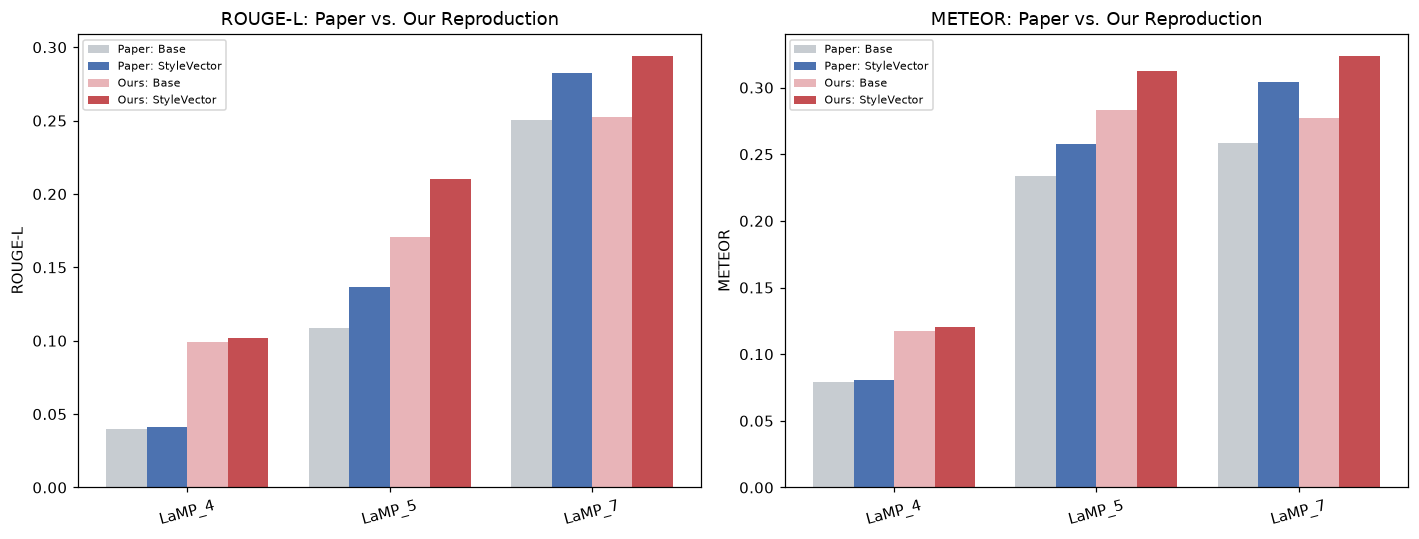

In [104]:
# Cell 6.3 — Grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ["ROUGE-L", "METEOR"]):
    sub = comparison_table[comparison_table["Metric"] == metric]
    x = np.arange(len(sub))
    width = 0.2
    ax.bar(x - 1.5*width, sub["Paper: Base"], width, label="Paper: Base", color="#c7ccd1")
    ax.bar(x - 0.5*width, sub["Paper: StyleVector"], width, label="Paper: StyleVector", color="#4c72b0")
    ax.bar(x + 0.5*width, sub["Ours: Base"], width, label="Ours: Base", color="#e8b4b8")
    ax.bar(x + 1.5*width, sub["Ours: StyleVector"], width, label="Ours: StyleVector", color="#c44e52")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["Task"], rotation=15)
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}: Paper vs. Our Reproduction")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "paper_vs_reproduction.png", dpi=150)
plt.show()

In [61]:
# Cell 6.4 — Qualitative case study: sample generations side by side
N_CASES = 5
for task in TASKS:
    print(f"\n{'='*25} {task} — sample cases {'='*25}")
    sample = results_df[results_df["task"] == task].head(N_CASES)
    for _, row in sample.iterrows():
        print(f"\n[user {row['user_id']}]")
        print(f"  gold: {row['gold'][:80]!r}")
        print(f"  base: {row['pred_baseline'][:80]!r}")
        print(f"  SV  : {row['pred_stylevector'][:80]!r}")


========================= LaMP_4 — sample cases =========================

[user 31965]
  gold: "Two More Patriots Players Decide Not To Visit Trump's White House"
  base: 'Here are a few potential headlines for the article:\n\n1. "Blount Expresses Discom'
  SV  : 'Here are a few potential headlines for the article:\n\n1. "Blount Expresses Discom'

[user 31815]
  gold: "America's Sweetheart Susan Lucci Opens Up About Love, Fans and the Little Boy Wh"
  base: 'Here are a few potential headlines for the article:\n\n1. "Susan Lucci Proves Crit'
  SV  : 'Here are a few potential headlines for the article:\n\n1. "Susan Lucci Proves Crit'

[user 31666]
  gold: 'A Grapefruit Smoothie for Morning Greatness'
  base: 'Here are a few headline options for the article about citrus:\n\n1. "Winter\'s Citr'
  SV  : 'Here are a few headline options for the article about citrus:\n\n1. "Winter\'s Citr'

[user 311001]
  gold: 'Solving Holiday Time-Share Dilemmas'
  base: 'Here are a few potential headlin

## Part 7 — Save All Results

In [62]:
# Cell 7.1 — Export everything
results_df.to_csv(CHECKPOINT_DIR / "full_results.csv", index=False)
comparison_table.to_csv(CHECKPOINT_DIR / "paper_comparison_table.csv", index=False)

print("Saved to:", CHECKPOINT_DIR.resolve())
print(" - full_results.csv")
print(" - paper_comparison_table.csv")
print(" - best_config.json")
print(" - paper_vs_reproduction.png")

Saved to: /home/user/stylevector_project/checkpoints_final
 - full_results.csv
 - paper_comparison_table.csv
 - best_config.json
 - paper_vs_reproduction.png


In [109]:
del model
torch.cuda.empty_cache()